<a href="https://colab.research.google.com/github/ramyanagavelli463-maker/N.Ramya/blob/main/predictive_analytics_historical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance statsmodels scikit-learn

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [3]:
data = yf.download(
    'AAPL',
    start='2018-01-01',
    end='2023-12-31'
)

data.head()


/tmp/ipykernel_1450/489635175.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.232376,40.241720,39.531708,39.741910,102223600
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2018-01-04,40.412231,40.514997,40.190354,40.297788,89738400
2018-01-05,40.872322,40.958737,40.416888,40.507975,94640000
2018-01-08,40.720512,41.014792,40.622416,40.720512,82271200


In [4]:
data = data[['Close']]

data.head()

Price,Close
Ticker,AAPL
Date,
2018-01-02,40.232376
2018-01-03,40.225372
2018-01-04,40.412231
2018-01-05,40.872322
2018-01-08,40.720512


In [5]:
print(data.shape)
print(data.isnull().sum())
print(data.describe())


(1509, 1)
Price  Ticker
Close  AAPL      0
dtype: int64
Price         Close
Ticker         AAPL
count   1509.000000
mean     107.531711
std       50.795830
min       33.707924
25%       51.098343
50%      120.137703
75%      149.812988
max      195.723831


In [6]:
data = data.dropna()

print(data.isnull().sum())

Price  Ticker
Close  AAPL      0
dtype: int64


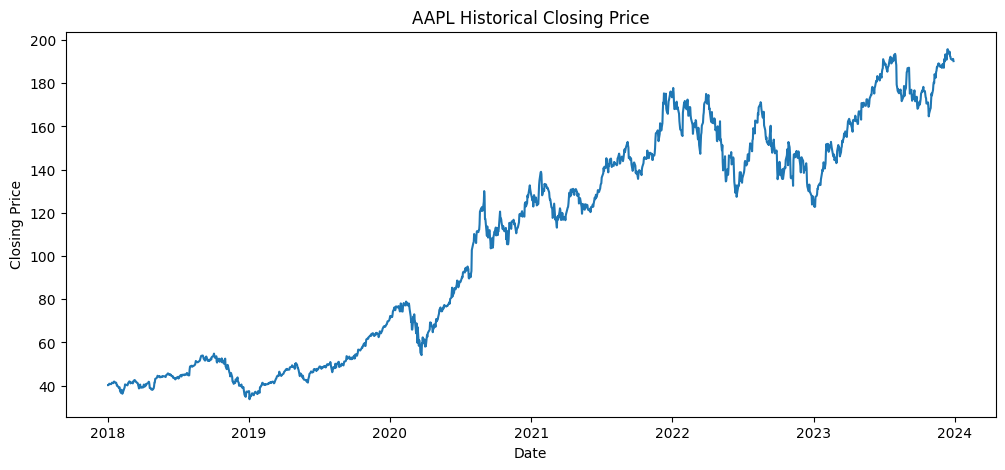

In [7]:
plt.figure(figsize=(12,5))

plt.plot(data['Close'])

plt.title('AAPL Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [8]:
train_size = int(len(data) * 0.8)

train = data['Close'][:train_size]
test = data['Close'][train_size:]

print("Training data:", len(train))
print("Testing data:", len(test))


Training data: 1207
Testing data: 302


In [9]:
model = ARIMA(train, order=(5,1,2))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/p

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1207
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -2584.400
Date:                Tue, 22 Sep 2026   AIC                           5184.801
Time:                        07:17:34   BIC                           5225.561
Sample:                             0   HQIC                          5200.151
                               - 1207                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.8737      0.034    -54.388      0.000      -1.941      -1.806
ar.L2         -1.0551      0.054    -19.498      0.000      -1.161      -0.949
ar.L3         -0.1251      0.049     -2.529      0.0

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [10]:
# Select Close price
close_data = data['Close']

# If Close is a DataFrame, convert it to a Series
if isinstance(close_data, pd.DataFrame):
    close_data = close_data.iloc[:, 0]

# Remove missing values
close_data = close_data.dropna()

# Make sure the index is a proper date index
close_data.index = pd.to_datetime(close_data.index)

print(close_data.head())
print(close_data.shape)

Date
2018-01-02    40.232376
2018-01-03    40.225372
2018-01-04    40.412231
2018-01-05    40.872322
2018-01-08    40.720512
Name: AAPL, dtype: float64
(1509,)


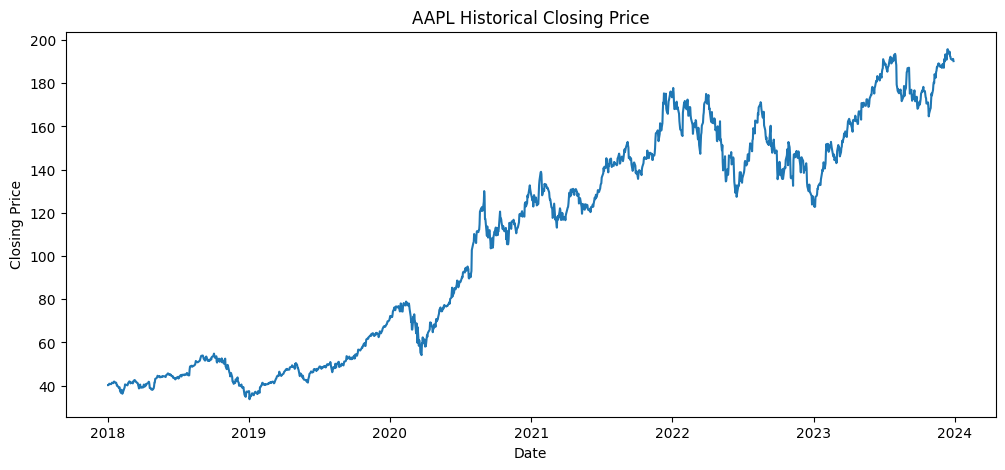

In [11]:
plt.figure(figsize=(12,5))

plt.plot(close_data)

plt.title('AAPL Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [12]:
train_size = int(len(close_data) * 0.8)

train = close_data.iloc[:train_size]
test = close_data.iloc[train_size:]

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 1207
Testing data: 302


In [15]:
# Create a simpler ARIMA model
# Ensure the training data has a defined frequency for forecasting
train = train.asfreq('D') # Set daily frequency

model = ARIMA(train, order=(1, 1, 1))

model_fit = model.fit()

print("ARIMA model fitted successfully!")

ARIMA model fitted successfully!


In [16]:
forecast = model_fit.forecast(steps=len(test))

print("Forecast created successfully!")
print(forecast[:10])

Forecast created successfully!
2022-10-18    139.424573
2022-10-19    139.363326
2022-10-20    139.348695
2022-10-21    139.345200
2022-10-22    139.344366
2022-10-23    139.344166
2022-10-24    139.344118
2022-10-25    139.344107
2022-10-26    139.344104
2022-10-27    139.344104
Freq: D, Name: predicted_mean, dtype: float64


In [ ]:
comparison = pd.DataFrame({
    'Actual': test.to_numpy(),
    'Predicted': forecast.to_numpy()
})

print(comparison.head(10))

In [ ]:
mae = mean_absolute_error(
    test.to_numpy(),
    forecast.to_numpy()
)

print("Mean Absolute Error:", mae)

In [ ]:
rmse = np.sqrt(
    mean_squared_error(
        test.to_numpy(),
        forecast.to_numpy()
    )
)

print("Root Mean Squared Error:", rmse)

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test.to_numpy(), label='Actual')
plt.plot(forecast.to_numpy(), label='Predicted')

plt.title('Actual vs Predicted AAPL Closing Price')
plt.xlabel('Days')
plt.ylabel('Closing Price')

plt.legend()
plt.show()

In [ ]:
# Train final model using all historical data
final_model = ARIMA(close_data, order=(1, 1, 1))

final_model_fit = final_model.fit()

# Forecast next 30 days
future_forecast = final_model_fit.forecast(steps=30)

print("Next 30 days forecast:")
print(future_forecast)

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(close_data, label='Historical Data')

future_index = range(
    len(close_data),
    len(close_data) + 30
)

plt.plot(
    future_index,
    future_forecast.to_numpy(),
    label='30-Day Forecast'
)

plt.title('AAPL 30-Day Future Forecast')
plt.xlabel('Days')
plt.ylabel('Closing Price')

plt.legend()
plt.show()

In [ ]:
future_forecast_df = pd.DataFrame({
    'Day': range(1, 31),
    'Predicted_Close_Price': future_forecast.to_numpy()
})

future_forecast_df.to_csv(
    'AAPL_30_Day_Forecast.csv',
    index=False
)

print("Forecast saved successfully!")

In [ ]:
print("MAE:", mae)
print("RMSE:", rmse)

print("\n30-Day Forecast:")
print(future_forecast_df)

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(close_data, label='Historical Data')

future_index = range(
    len(close_data),
    len(close_data) + 30
)

plt.plot(
    future_index,
    future_forecast.to_numpy(),
    label='30-Day Forecast'
)

plt.title('AAPL 30-Day Future Forecast')
plt.xlabel('Days')
plt.ylabel('Closing Price')

plt.legend()
plt.show()